In [18]:
from graph_transformer_long_range_niches.tl import pad_batch
from graph_transformer_long_range_niches._paths import CFG_FILES, RESULTS, FIG_PATH, LEGNINI23
from graph_transformer_long_range_niches.model import LitGNNTransformer, LitGNNTransformerMasked, LitPCATransformerMasked
from graph_transformer_long_range_niches.modules import LitGCNMasked, LitGCN
from graph_transformer_long_range_niches.pl import predict_gene_r2, compare_model_variance, plot_lfc_scatter,  CustomColormap, plot_attention_sender_receiver, plot_attention_sender_receiver, SelfAttentionRelevance, calculate_attention, normalized_attention, normalized_class_attention
from graph_transformer_long_range_niches.pp import prepare_geome_dataset, split_adata
from graph_transformer_long_range_niches.config import load_config
from graph_transformer_long_range_niches.tl.geome_dataloader import GraphAnnDataModule

import warnings
warnings.filterwarnings("ignore")

from torch_geometric.loader import DataLoader

from pathlib import Path
import wandb
import torch
import os

## plotting
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle

import scanpy as sc
import squidpy as sq

from sklearn.preprocessing import MinMaxScaler

# InterScale training


0. Create `config.yaml` file
1. Load `cfg` and `adata` object
2. Prepare PyG data
3. Train GNN (Pre-training)
4. Train Transformer (Fine-tuning, global interactions)

In [19]:
FOLDER = "legnini23"
cfg_path = "/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/config_files/Legnini_23/legnini23_genes_sample_gnntrans.yaml"
#cfg_path = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/config_files/CosmX_Pancreas/pancreas_gnntrans_conditon_sw_2.yaml'

### Load config and adata

In [3]:
cfg = load_config(cfg_path)

In [4]:
cfg.dataset.h5ad_data

'/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/legnini23.h5ad'

In [5]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [6]:
#adata.X = adata.layers['norm_ftsqrt']
print(adata.X[:5, :5])

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 7 stored elements and shape (5, 5)>
  Coords	Values
  (1, 0)	0.7994269132614136
  (1, 1)	0.7994269132614136
  (3, 0)	0.8773584961891174
  (3, 1)	2.632075548171997
  (4, 0)	0.5310913920402527
  (4, 1)	0.5310913920402527
  (4, 3)	0.17703045904636383


In [7]:
# clustering

In [8]:
train_size, val_size, test_size = float(cfg.dataset.train_size), float(cfg.dataset.val_size), float(cfg.dataset.test_size)
print(f'Train size: {train_size}, val size: {val_size} and test size: {test_size}')

Train size: 0.7, val size: 0.2 and test size: 0.1


In [9]:
split_adata(adata, split_obs=cfg.dataset.obs_split, val_size=val_size, test_size=test_size, seed = cfg.optim.seed, stratify_groups = cfg.dataset.prediction_obs)

Test size > 0
{'counts': {'train': 23890, 'val': 13228, 'test': 6644}, 'groups': {'train': ['slide1_C2-1', 'slide1_C2-3', 'slide1_C2-5', 'slide4_A2-2', 'slide1_B2-3', 'slide1_A2-1', 'slide4_B2-3', 'slide4_A2-1', 'slide4_A2-3', 'slide1_A2-2', 'slide1_B2-2'], 'val': ['slide4_B2-2', 'slide1_C2-2', 'slide1_D2-3', 'slide1_D2-2'], 'test': ['slide4_B2-1', 'slide1_B2-1']}}


AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [10]:
# cross-gene vs cross-cell evaluation
cfg.set_new_allowed(True)
cfg.defrost()
cfg.optim.cross_corr = 'gene'
cfg.dataset.batch_size = 3
cfg.dataset.pct_mask_nodes = 0.3
cfg.model.decoder.type = 'linear'
cfg.transformer.dim_feedforward = 64
#cfg.dataset.spatial_neigbors_kwargs.radius = 0
cfg.freeze()

In [11]:
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)
pyg_data_list

coord_type: generic
library_key: sample
n_neighs: 6
radius: 200
call new
call new
call new
call new


[[Data(x=[3023, 88], edge_index=[2, 30734], obs_names=[3023]),
  Data(x=[1694, 88], edge_index=[2, 19178], obs_names=[1694]),
  Data(x=[1701, 88], edge_index=[2, 19342], obs_names=[1701]),
  Data(x=[2241, 88], edge_index=[2, 21678], obs_names=[2241]),
  Data(x=[2870, 88], edge_index=[2, 31620], obs_names=[2870]),
  Data(x=[1640, 88], edge_index=[2, 18170], obs_names=[1640]),
  Data(x=[1958, 88], edge_index=[2, 21830], obs_names=[1958]),
  Data(x=[2630, 88], edge_index=[2, 22200], obs_names=[2630]),
  Data(x=[2506, 88], edge_index=[2, 22690], obs_names=[2506]),
  Data(x=[1984, 88], edge_index=[2, 16736], obs_names=[1984]),
  Data(x=[1643, 88], edge_index=[2, 13926], obs_names=[1643])],
 [Data(x=[3510, 88], edge_index=[2, 40186], obs_names=[3510]),
  Data(x=[4318, 88], edge_index=[2, 48666], obs_names=[4318]),
  Data(x=[3621, 88], edge_index=[2, 39762], obs_names=[3621]),
  Data(x=[1779, 88], edge_index=[2, 13146], obs_names=[1779])],
 [Data(x=[3299, 88], edge_index=[2, 36290], obs_names

In [12]:
train_ds, val_ds, test_ds = pyg_data_list[0], pyg_data_list[1], pyg_data_list[2]

In [13]:
# set number of classes and number of features
cfg.dataset.merge_from_list(['num_features', len(train_ds[0].x[1])])
if 'classification' in cfg.dataset.prediction_task:
  cfg.dataset.merge_from_list(['num_classes', len(train_ds[0].y[1])])

In [14]:
dm = GraphAnnDataModule(datas=pyg_data_list, 
                           num_workers=1, 
                           batch_size=int(cfg.dataset.batch_size), 
                           pct_mask_nodes=cfg.dataset.pct_mask_nodes,
                           learning_type="node")

Masked dataloader


In [15]:
model = LitPCATransformerMasked(cfg)

cross-gene per cellcorrelation metrics


In [16]:
import math
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor, EarlyStopping, Callback, Timer
import pytorch_lightning as pl

class MetricsHistory(Callback):
    def __init__(self):
        super().__init__()
        self.history = []
        
    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        # Convert tensor values to float
        epoch_dict = {k: v.item() if hasattr(v, 'item') else v 
                     for k, v in metrics.items()}
        epoch_dict['epoch'] = trainer.current_epoch
        self.history.append(epoch_dict)

steps_per_epoch = math.ceil(len(train_ds) / cfg.dataset.batch_size)
early_stop_callback = EarlyStopping(monitor="val_r2", min_delta=0.05, patience=10*steps_per_epoch, verbose=False, mode="max")
lr_monitor = LearningRateMonitor(logging_interval='epoch')
timer = Timer()
history_callback = MetricsHistory()

In [17]:
trainer = pl.Trainer(min_epochs=1, 
                     max_epochs=500,
                     enable_progress_bar=False,
                     callbacks=[lr_monitor, early_stop_callback, timer, history_callback],
                     log_every_n_steps=steps_per_epoch,
                     # Sanity checks: Debugging model
                     #overfit_batches=1,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [18]:
trainer.fit(model, dm)
trainer.validate(model, dm)


  | Name                   | Type                       | Params | Mode 
------------------------------------------------------------------------------
0 | loss                   | GaussianNLLLoss            | 0      | train
1 | graph_pred_linear_list | ModuleList                 | 0      | train
2 | graph_pred_linear      | Linear                     | 2.9 K  | train
3 | norm_input             | LayerNorm                  | 64     | train
4 | transformer_encoder    | TransformerNodeEncoderHook | 17.2 K | train
  | other params           | n/a                        | 32     | n/a  
------------------------------------------------------------------------------
20.2 K    Trainable params
0         Non-trainable params
20.2 K    Total params
0.081     Total estimated model params size (MB)
29        Modules in train mode
0         Modules in eval mode


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_mse          │     50.8740119934082      │
│     val_pearson_corr      │    0.6837231516838074     │
│          val_r2           │    0.44291630387306213    │
└───────────────────────────┴───────────────────────────┘

[{'val_mse': 50.8740119934082,
  'val_r2': 0.44291630387306213,
  'val_pearson_corr': 0.6837231516838074}]

In [19]:
trainer.test(model, dm)

Test step (regression) - Loss: 2.3521, MSE: 54.1061, R2: 0.4634


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_mse          │     54.1060905456543      │
│     test_pearson_corr     │    0.7148393988609314     │
│          test_r2          │    0.46341440081596375    │
└───────────────────────────┴───────────────────────────┘

[{'test_mse': 54.1060905456543,
  'test_r2': 0.46341440081596375,
  'test_pearson_corr': 0.7148393988609314}]

In [22]:
trainer.save_checkpoint(Path(RESULTS, 'legnini23', 'gcntrans.ckpt'))

In [23]:
# After training, get the time metrics
total_time = timer.time_elapsed("train")  # total training time in seconds
avg_epoch_time = timer.time_elapsed("train") / trainer.current_epoch  # average time per epoch

print(f"Total training time: {total_time:.2f} seconds")
print(f"Average epoch time: {avg_epoch_time:.2f} seconds")

Total training time: 546.29 seconds
Average epoch time: 3.03 seconds


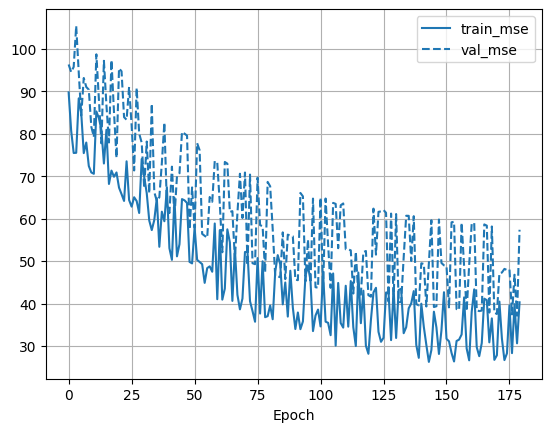

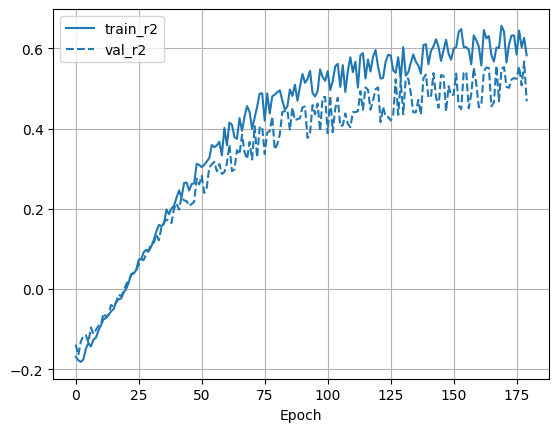

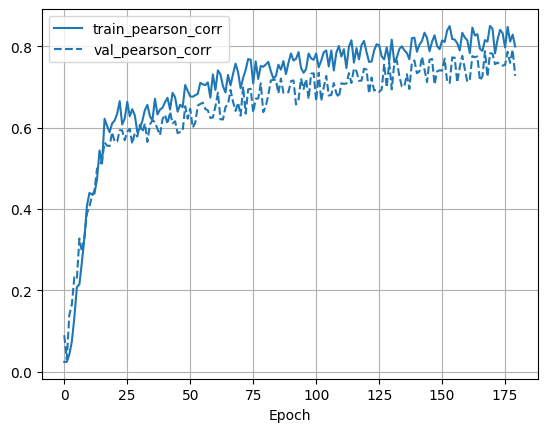

In [24]:
def plot_history(history_callback, subset_term=None):
    history = pd.DataFrame(history_callback.history)
    if subset_term is not None:
        history = history[[c for c in history.columns if subset_term in c]]
    ax = history[[c for c in history.columns if 'train' in c]].plot()
    plt.gca().set_prop_cycle(None)
    history[[c for c in history.columns if 'val' in c]].plot(style='--', ax=ax)
    plt.grid(True)
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

plot_history(history_callback, subset_term='mse')
plot_history(history_callback, subset_term='r2')
plot_history(history_callback, subset_term='pearson_corr')

### Test dataloader

In [20]:
dm.setup("test")

In [26]:
# dm.setup("fit")
# for i, batch in enumerate(dm.train_dataloader()):
#     print(batch, np.unique(batch.batch))
#     _, mask_idx = apply_mask(batch)

# Model evaluation

Evaluation on test slides slide4_A2-3 (ctrl) and slide4_B2-2 (SHH).

In [26]:
shh_slides = ['slide4_A2-3', 'slide4_B2-2']

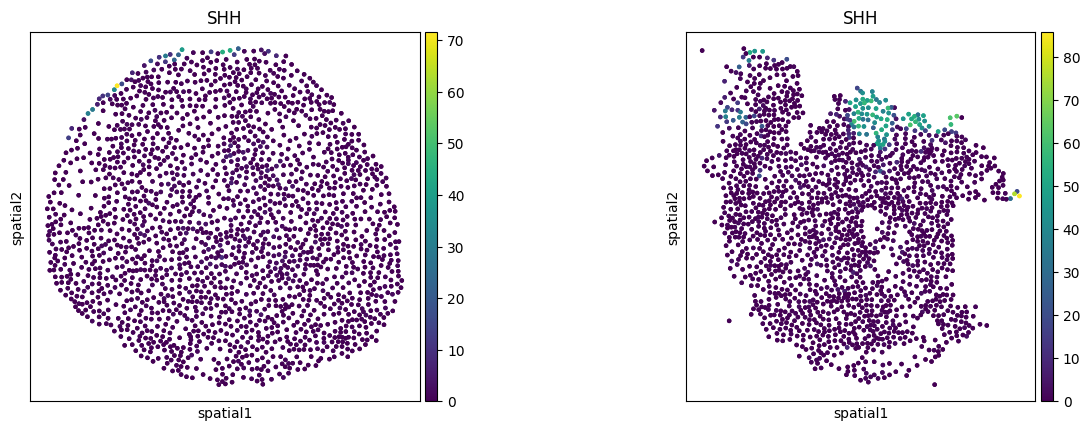

In [28]:
sq.pl.spatial_scatter(
    adata,
    library_key = 'sample',
    library_id = shh_slides,
    color = ['SHH'],
    shape= None,
    size = 20, 
)

## R2 score 

Input: reconstructed X (GNN), reconstructed X (GNNTrans)

Output: R2 scores for each

In [21]:
pre_trained_gcn = Path(RESULTS, 'legnini23', 'gcn_pretrained.ckpt')
gcn_model = LitGCNMasked.load_from_checkpoint(pre_trained_gcn)
gcntrans_model = LitGNNTransformerMasked.load_from_checkpoint(Path(RESULTS, 'legnini23', 'gcntrans.ckpt'))

cross-gene per cellcorrelation metrics
cross-gene per cellcorrelation metrics
cross-gene correlation metrics


Top 30 genes for x_pred_local model:
           gene        r2    r2_log
13   Circ.CDR1  0.426586  0.355284
78       STMN2  0.326372  0.282447
55      NKX6.1  0.309722  0.269815
82       TUBB3  0.172108  0.158804
0   AC129492.1  0.104486  0.099380
6         ARG1  0.000000  0.000000
87       TREM2  0.000000  0.000000
22         FOS -0.044145 -0.045149
77        SOX2 -0.203596 -0.227648
64        PAX6 -0.270087 -0.314830
14   Circ.RMST -0.294736 -0.349183
42        JUNB -0.394466 -0.501645
41         JUN -0.515183 -0.723983
70       PTCH1 -0.572994 -0.850956
71      PTPRZ1 -0.591053 -0.894169
17        DBX1 -0.593008 -0.898962
43       KLF13 -0.600800 -0.918292
69       PROM1 -0.780236 -1.515201
46        MAP2 -0.803383 -1.626498
83       VAMP2 -0.936805 -2.761532
84      ZNF609 -0.951782 -3.032020
5          ARC -1.082976       NaN
54      NKX2.2 -1.091618       NaN
52     NEUROG2 -1.130523       NaN
32        GLI3 -1.384743       NaN
51     NEUROD1 -1.627733       NaN
59    OIP5.AS1 -1

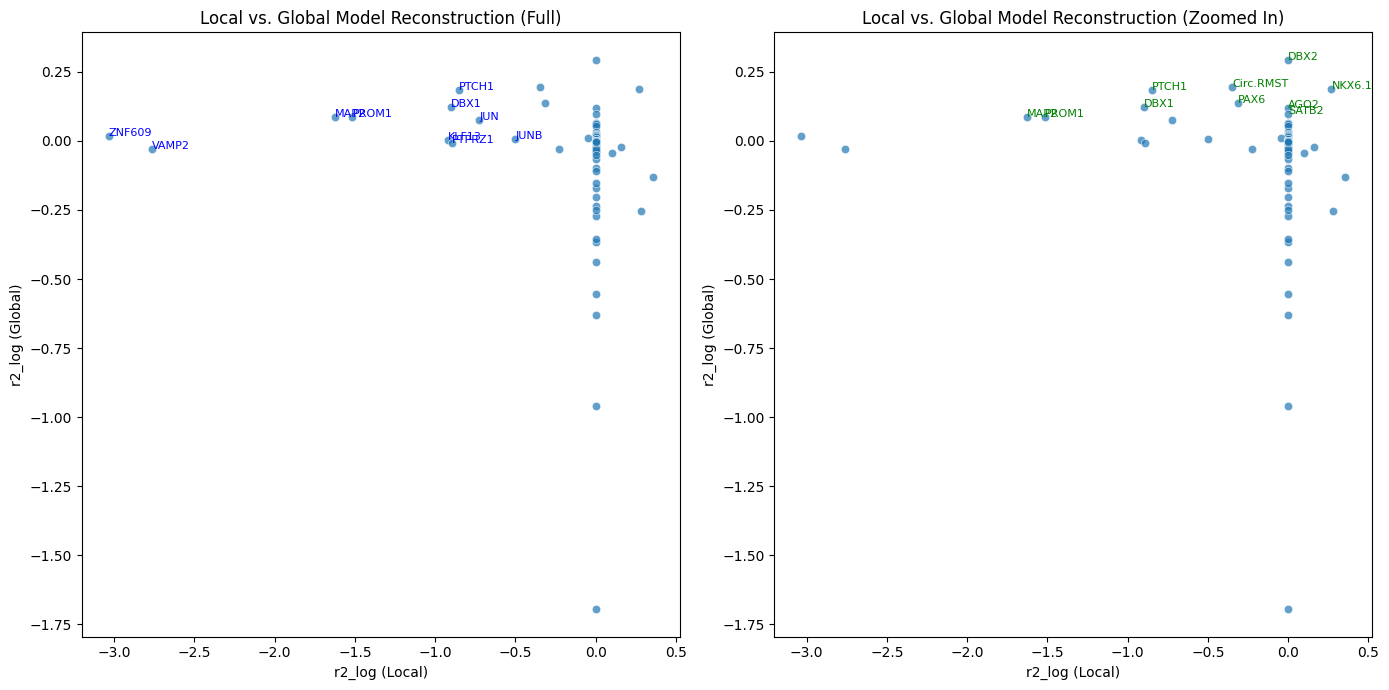

Top 30 genes for x_pred_local model:
          gene        r2    r2_log
78      STMN2  0.496125  0.402879
64       PAX6  0.300838  0.263008
55     NKX6.1  0.238526  0.213922
13  Circ.CDR1  0.180388  0.165843
46       MAP2  0.157425  0.146198
77       SOX2  0.127914  0.120369
82      TUBB3  0.088188  0.084513
53     NKX2.1  0.000000  0.000000
80       TBR1  0.000000  0.000000
87      TREM2  0.000000  0.000000
41        JUN -0.379503 -0.477234
71     PTPRZ1 -0.488013 -0.669457
70      PTCH1 -0.499482 -0.692112
51    NEUROD1 -0.563778 -0.829604
17       DBX1 -0.954893 -3.098710
40       ISL1 -1.004892       NaN
29       GAD1 -1.127520       NaN
47       MNX1 -1.175798       NaN
54     NKX2.2 -1.191552       NaN
14  Circ.RMST -1.215240       NaN
84     ZNF609 -1.800303       NaN
39       IRX3 -2.411211       NaN
26      FOXA2 -2.605793       NaN
69      PROM1 -2.666883       NaN
24      FOSL2 -2.776209       NaN
52    NEUROG2 -2.950096       NaN
34       HES6 -3.107258       NaN
31       G

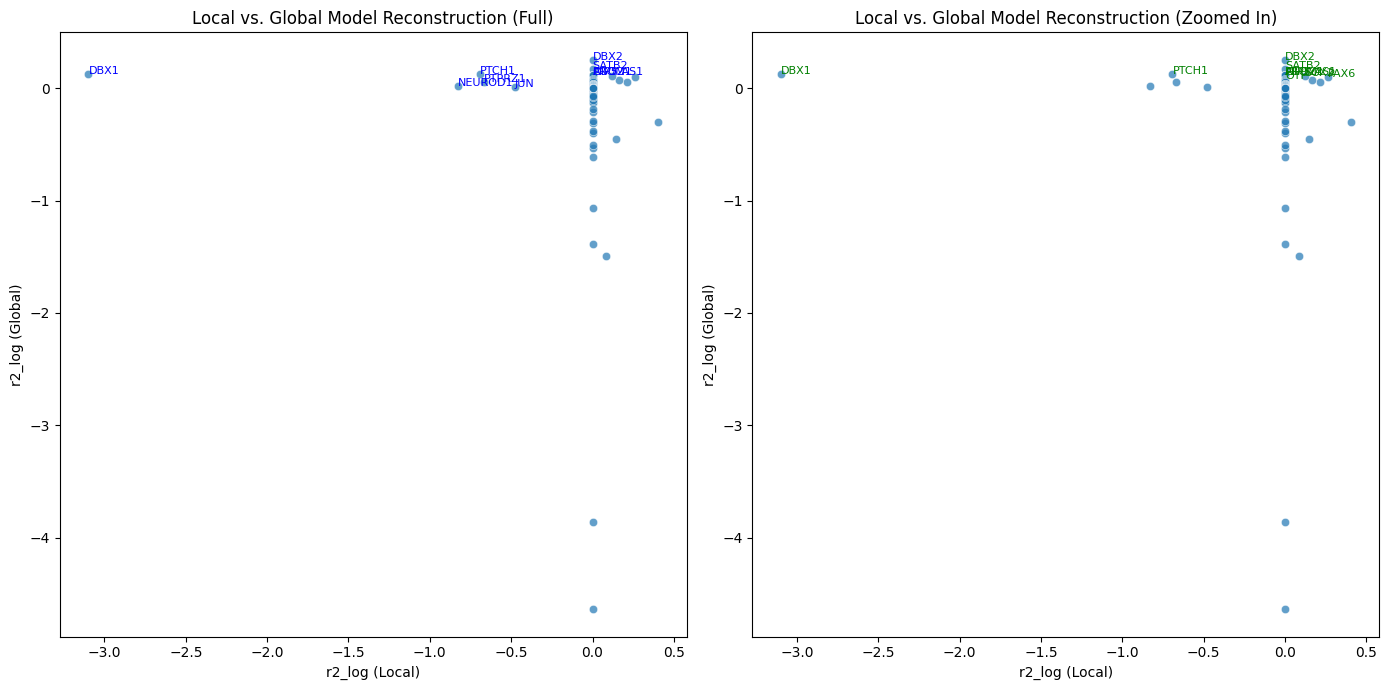

In [47]:
for i, batch in enumerate(dm.test_dataloader()):
    z, x = gcn_model.evaluation(batch)
    _, _, _, index_nodes, dec_out = gcntrans_model.evaluation(batch)
    start = 0
    for batch_idx in np.unique(batch.batch):
        df_list = []
        # GCN results
        x_batch = x[batch.batch == batch_idx]
        z_batch = z[batch.batch == batch_idx]
        batch_obs_names_str = batch.obs_names[batch.batch == batch_idx].numpy().astype(int).astype(str)[index_nodes[batch_idx]]
        idx_nodes = np.where(adata.obs_names.isin(batch_obs_names_str))
        nr_cells = len(batch_obs_names_str)

        local_batch_obs_names_str = batch.obs_names[batch.batch == batch_idx].numpy().astype(int).astype(str)
        index_nodes_local = np.intersect1d(np.arange(len(local_batch_obs_names_str)), index_nodes[batch_idx], assume_unique=True)

        sub_adata = adata[adata.obs_names.isin(batch_obs_names_str)].copy()
        sub_adata.layers['x_pred_global'] = dec_out[start:start + nr_cells].detach().numpy()
        sub_adata.layers['x_pred_local'] = x_batch[index_nodes_local].detach().numpy()
        
        df_list.append(predict_gene_r2(sub_adata, 'x_pred_local', 30))
        df_list.append(predict_gene_r2(sub_adata, 'x_pred_global', 30))

        combined_df = compare_model_variance(df1 = df_list[0], df2 = df_list[1], 
                         model1_name = "Local", 
                         model2_name = "Global",
                         metric = 'r2_log')

        print(combined_df)

        plot_lfc_scatter(combined_df, "Local", "Global", metric = 'r2_log')

        start = start + nr_cells

## Attention gene (program) masking

In [69]:
sub_adata, attention_matrix_dict_gex, transformer_in_dict_gex, transformer_out_dict_gex = calculate_attention(adata, cfg, gcntrans_model, obs_col = 'sample', class_name = 'slide4_B2-2', library_key='sample')

['slide4_B2-2']
coord_type: generic
library_key: sample
n_neighs: 6
radius: 200
call new
call new
batch:  DataBatch(x=[1779, 88], edge_index=[2, 13146], obs_names=[1779], batch=[1779], ptr=[2]) library_id slide4_B2-2
1780
cls 1779
library_mask:  1779  library_indices:  1779  index_nodes : 1779


In [72]:
# won't work for larger than 1 attention_matrix_dict
attention_matrix = attention_matrix_dict_gex['slide4_B2-2']
class_names = sub_adata.obs['shh_distance_group']
obs_names = sub_adata.obs_names
obs_name_to_cell_type = dict(zip(obs_names, class_names))
attention_matrix = attention_matrix.rename(index=obs_name_to_cell_type, columns=obs_name_to_cell_type)

In [74]:
 norm_attn_matrix = normalized_class_attention(attention_matrix)
norm_attn_matrix

,far,mid,near,shh
far,0.368333,0.347469,0.347237,0.336993
mid,0.373126,0.351219,0.353679,0.338444
near,0.401143,0.378185,0.377621,0.370359
shh,0.379259,0.362807,0.356031,0.342978


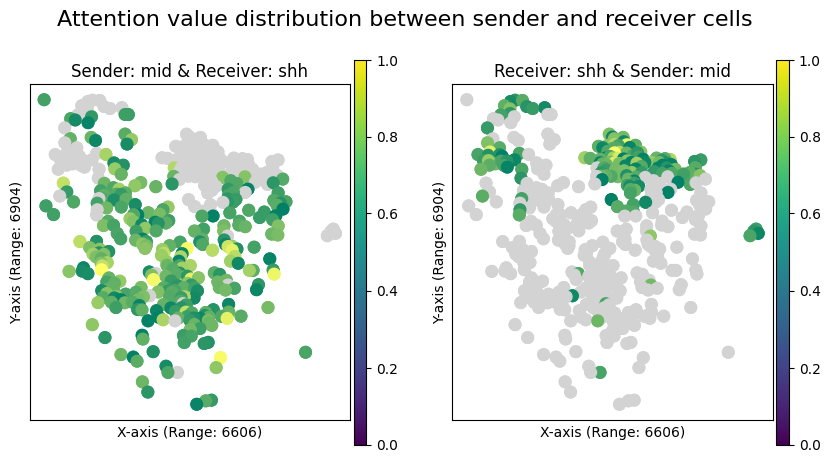

In [71]:
plot_attention_sender_receiver(
        sub_adata,
        sender = 'mid',
        receiver = 'shh',
        cell_type_key = 'shh_distance_group',
        attn_matrix_key ='attention_matrix',
    )

### SHH distance

In [50]:
from scipy.sparse import issparse
from scipy.spatial import distance_matrix

# Identify SHH center
shh_threshold = 4.5

shh_values = adata[:, 'SHH'].X
# If sparse, convert to dense
if issparse(shh_values):
    shh_values = shh_values.toarray()
# Ensure it's a 1D array
shh_values = shh_values.flatten()

adata.obs['shh_cluster'] = np.where(shh_values < shh_threshold, str(0), str(1))

In [51]:
# Compute distances based on spatial coordinates
spatial_key = "spatial"  # Modify this if your spatial coordinates are stored differently
coords = adata.obsm[spatial_key]

# Extract indices of SHH cluster cells
shh_indices = np.where(adata.obs['shh_cluster'] == "1")[0]

if len(shh_indices) > 0:
    # Compute distances to the closest SHH cluster cell
    dists = distance_matrix(coords, coords[shh_indices])
    min_dists = np.min(dists, axis=1)

    # Define distance-based categories (adjust thresholds as needed)
    bins = [0, 30, 60, np.inf]  # Example distance thresholds
    labels = ["near", "mid", "far"]
    adata.obs['shh_distance_group'] = pd.cut(min_dists, bins=bins, labels=labels)
    # Convert to categorical and add "shhh" as a valid category
    adata.obs['shh_distance_group'] = adata.obs['shh_distance_group'].astype("category")
    adata.obs['shh_distance_group'] = adata.obs['shh_distance_group'].cat.add_categories("shh")
    
    # Override SHH cluster cells with label "shhh"
    adata.obs.loc[adata.obs['shh_cluster'] == "1", 'shh_distance_group'] = "shh"
else:
    adata.obs['shh_distance_group'] = "undefined"

In [52]:
shh_slides = ['slide4_A2-1', 'slide4_B2-2']

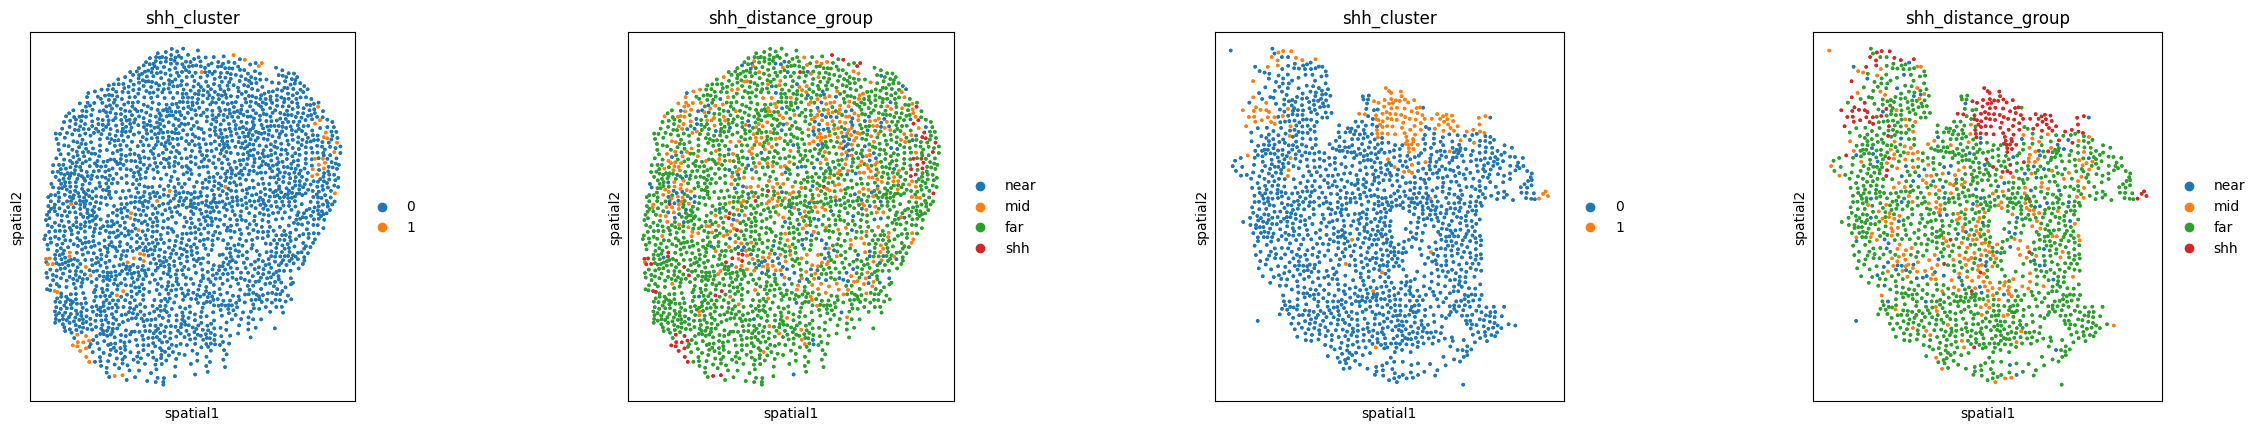

In [53]:
sq.pl.spatial_scatter(
    adata,
    library_key = 'sample',
    library_id = shh_slides,
    color = ['shh_cluster', 'shh_distance_group'],
    shape= None,
    size = 10, 
)

In [31]:
# samples in test set 
adata[adata.obs['split'] == 'test'].obs.groupby(['split', 'sample', 'condition']).size()

split  sample       condition
test   slide1_B2-1  SHH          3299
       slide4_B2-1  SHH          3345
dtype: int64

In [32]:
dm.setup('test')

### GNNTransformer

In [33]:
def evaluate_batch(model_transformer, batch):
    self_attention_relevance = SelfAttentionRelevance(model_transformer.transformer_encoder)
    
    attention_matrix_dict = {}
    transformer_in_dict = {}
    transformer_out_dict = {}
    
    print(batch)
    transformer_in, transformer_out, src_padding_mask, index_nodes, dec_out = model_transformer.evaluation(batch)
    I = self_attention_relevance.generate_relevance(transformer_in, src_padding_mask)
    cls = I[:1, 1:].cpu().detach().numpy() 
    attention_matrix_df = pd.DataFrame(
        I[1:, 1:].cpu().detach().numpy(),
        index=sub_adata.obs_names[index_nodes[0]],
        columns=sub_adata.obs_names[index_nodes[0]]
    )
    attention_matrix_dict[str(library_id)] = attention_matrix_df
    transformer_in_dict[str(library_id)] = transformer_in
    transformer_out_dict[str(library_id)] = transformer_out

In [34]:
for i, batch in enumerate(dm.test_dataloader()):
    print(batch)

DataBatch(x=[6644, 88], edge_index=[2, 63920], obs_names=[6644], mask=[6644], batch=[6644], ptr=[3])


In [35]:
print(adata.obs_names)
print(batch.obs_names)
batch_obs_names_str = batch.obs_names.numpy().astype(int).astype(str)
adata.obs_names.isin(batch_obs_names_str).sum()

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '43752', '43753', '43754', '43755', '43756', '43757', '43758', '43759',
       '43760', '43761'],
      dtype='object', length=43762)
tensor([ 4717.,  4718.,  4719.,  ..., 40337., 40338., 40339.])


6644

In [36]:
import scipy
import anndata

def evaluate_embedding_space(adata, X, model_decoder):
    if scipy.sparse.issparse(X):
        X = torch.from_numpy(X.toarray()).float()
    W = model_decoder.weight
    emb = torch.matmul(X, W) # [N, E]

    for i in range(emb.shape[1]):
        adata.obs[f'emb_{i}'] = emb[:, i].detach().numpy()

    emb_np = emb.detach().numpy()
    adata_emb = anndata.AnnData(emb_np)
    adata_emb.var_names = [f"Embedding_{i}" for i in range(emb_np.shape[1])]  # Label embeddings
    adata_emb.obs['cell_type'] = ['None']*emb_np.shape[0]
    adata_emb.obs['shh_cluster'] = adata.obs['shh_cluster']
    shh_distance_group = list(adata.obs['shh_distance_group'])
    adata_emb.obs['shh_distance_group'] = shh_distance_group

    for i in range(emb_np.shape[1]):
        sub_adata.obs[f'emb_{i}'] = emb_np[:, i]
    
    sc.pl.heatmap(adata_emb, var_names=adata_emb.var_names, groupby='shh_distance_group')
    sq.tl.var_by_distance(
            adata=sub_adata,
            groups="1",
            cluster_key="shh_cluster",
            library_key="sample",
            covariates=["condition"],
        )
    sq.pl.var_by_distance(
        adata=sub_adata,
        design_matrix_key="design_matrix",
        var=['emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8'],
        anchor_key="1",
        covariate="condition",
        line_palette=["blue", "orange"],
        show_scatter=False,
        figsize=(6, 4),
    )

### Linear Decoder Weight Analysis

If your decoder is a simple linear layer  W
W, the weights themselves directly indicate the relationship between latent dimensions and genes.

In [20]:
weight_matrix = gcntrans_model.graph_pred_linear.weight.detach().cpu().numpy()  # Shape: (num_genes, latent_dim)

Text(0.5, 1.0, 'Linear Decoder Weight Matrix')

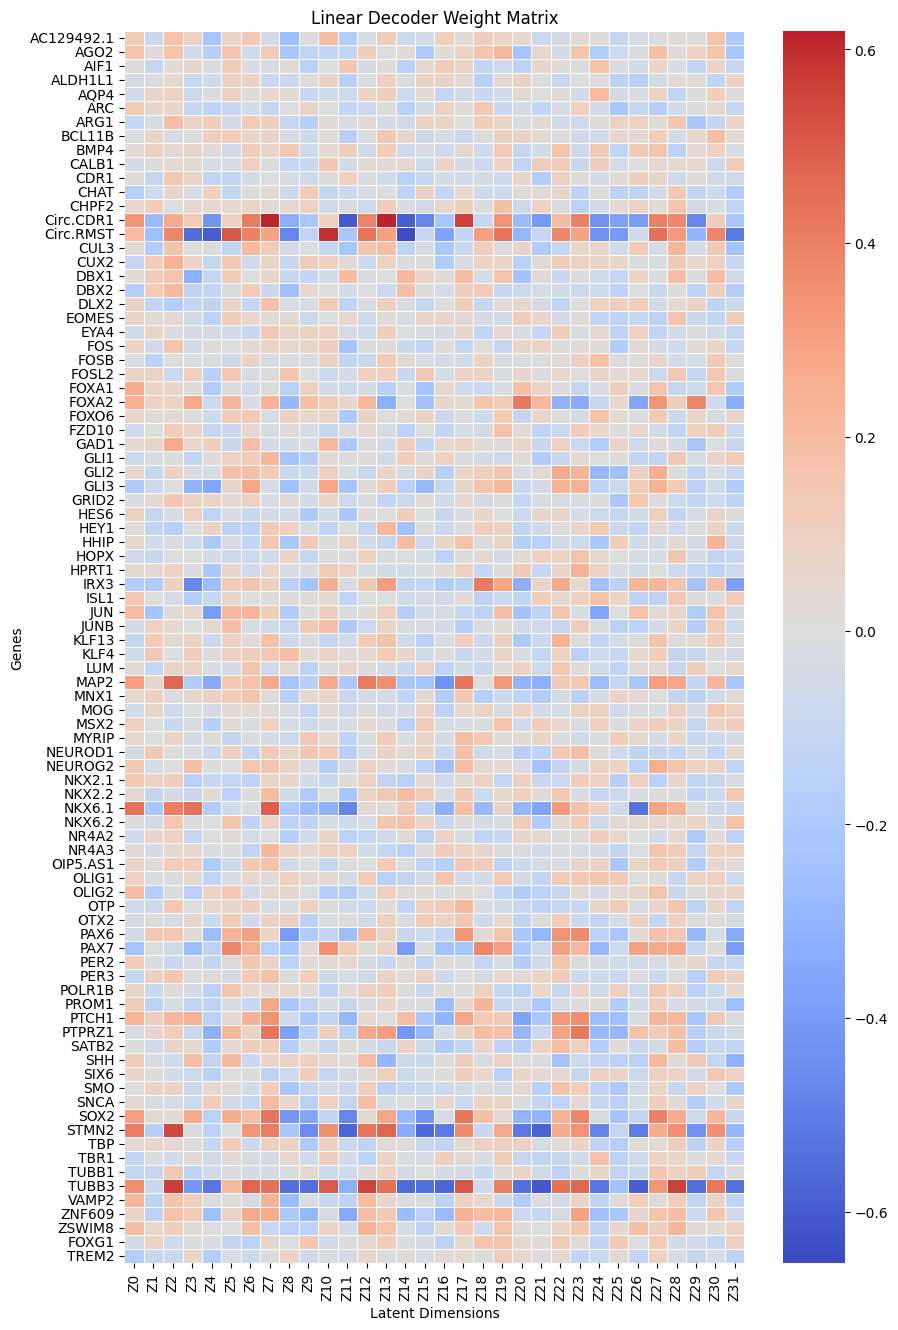

In [32]:
# Get gene names from adata
gene_names = adata.var_names.tolist()  # Convert to list for seaborn

# Generate latent dimension labels
latent_dim_labels = [f"Z{i}" for i in range(weight_matrix.shape[1])]

# Plot the heatmap
plt.figure(figsize=(10, 16))  # Adjust size based on data
sns.heatmap(weight_matrix, cmap="coolwarm", center=0, linewidths=0.5,
            xticklabels=latent_dim_labels, yticklabels=gene_names)

# Labels
plt.xlabel("Latent Dimensions")
plt.ylabel("Genes")
plt.title("Linear Decoder Weight Matrix")

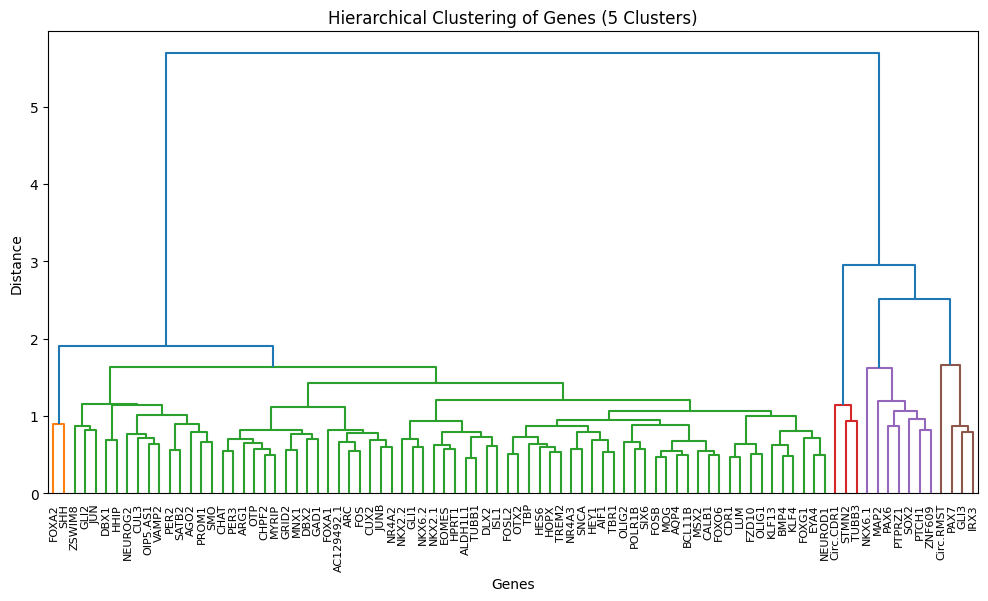

In [39]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

# Perform hierarchical clustering on gene weight matrix
linkage_matrix = linkage(weight_matrix, method="ward")

# Cut the dendrogram to get 5 clusters
num_clusters = 5
gene_clusters = fcluster(linkage_matrix, num_clusters, criterion="maxclust")

# Store cluster labels in adata.var
adata.var["latent_cluster"] = gene_clusters

# Plot dendrogram with cluster colors
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=adata.var_names.tolist(), leaf_rotation=90, leaf_font_size=8,
           color_threshold=np.sort(linkage_matrix[:, 2])[-num_clusters+1])  # Color branches for 5 clusters
plt.title("Hierarchical Clustering of Genes (5 Clusters)")
plt.xlabel("Genes")
plt.ylabel("Distance")
plt.show()

In [40]:
# Compute gene-gene correlation matrix
gene_correlation = np.corrcoef(weight_matrix)

In [58]:
import pandas as pd

gene_correlation = np.corrcoef(weight_matrix)
# Convert correlation matrix to a DataFrame
gene_corr_df = pd.DataFrame(gene_correlation, index=adata.var_names, columns=adata.var_names)

# Filter strongly correlated gene pairs (e.g., abs(corr) > 0.8)
strong_correlations = gene_corr_df.where(abs(gene_corr_df) > 0.7).stack().reset_index()
strong_correlations.columns = ["Gene1", "Gene2", "Correlation"]

# Remove self-correlations
strong_correlations = strong_correlations[strong_correlations["Gene1"] != strong_correlations["Gene2"]]
print(strong_correlations)

         Gene1      Gene2  Correlation
14   Circ.CDR1  Circ.RMST     0.730394
15   Circ.CDR1       MAP2     0.869399
16   Circ.CDR1       PAX6     0.746213
17   Circ.CDR1      PTCH1     0.729385
18   Circ.CDR1     PTPRZ1     0.782773
..         ...        ...          ...
175     ZNF609      PTCH1     0.763714
176     ZNF609     PTPRZ1     0.774799
177     ZNF609       SOX2     0.809774
178     ZNF609      STMN2     0.782033
179     ZNF609      TUBB3     0.777842

[96 rows x 3 columns]


In [59]:
# Filter for rows where 'SHH' appears in either column
shh_correlations = strong_correlations[(strong_correlations["Gene1"] == "SHH") | 
                                       (strong_correlations["Gene2"] == "SHH")]

# Print the results
print(shh_correlations)

     Gene1  Gene2  Correlation
46   FOXA2    SHH     0.751224
135    SHH  FOXA2     0.751224


In [60]:
# Filter for rows where 'SHH' appears in either column
shh_correlations = strong_correlations[(strong_correlations["Gene1"] == "SHH") | 
                                       (strong_correlations["Gene2"] == "SHH")]

# Print the results
print(shh_correlations)

     Gene1  Gene2  Correlation
46   FOXA2    SHH     0.751224
135    SHH  FOXA2     0.751224


### Dimensionality reduction of latent space

DataBatch(x=[6644, 88], edge_index=[2, 63920], obs_names=[6644], mask=[6644], batch=[6644], ptr=[3])
3299


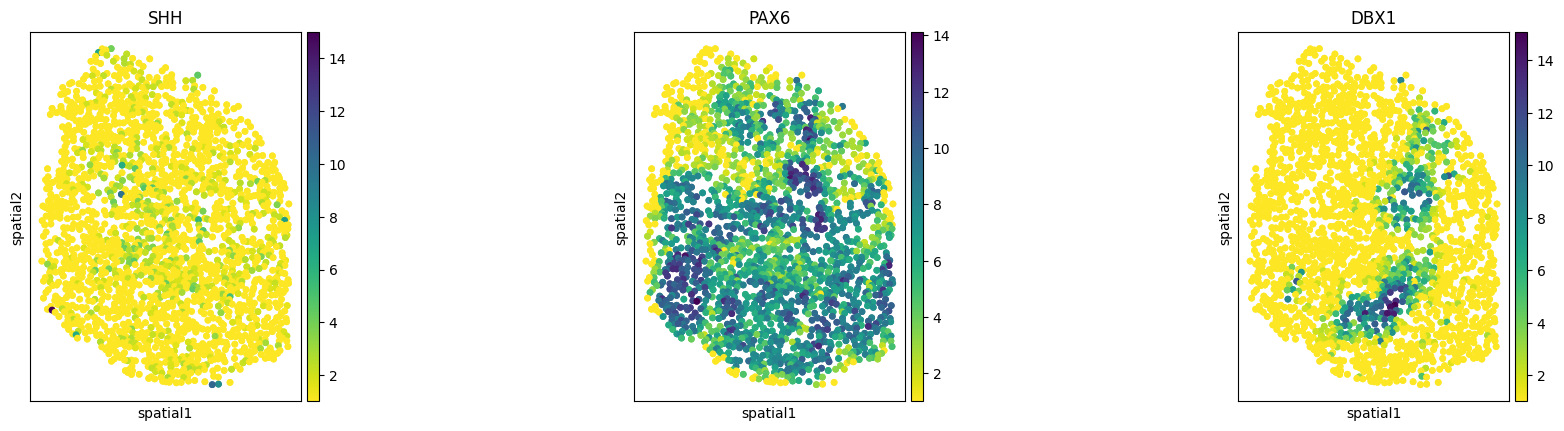

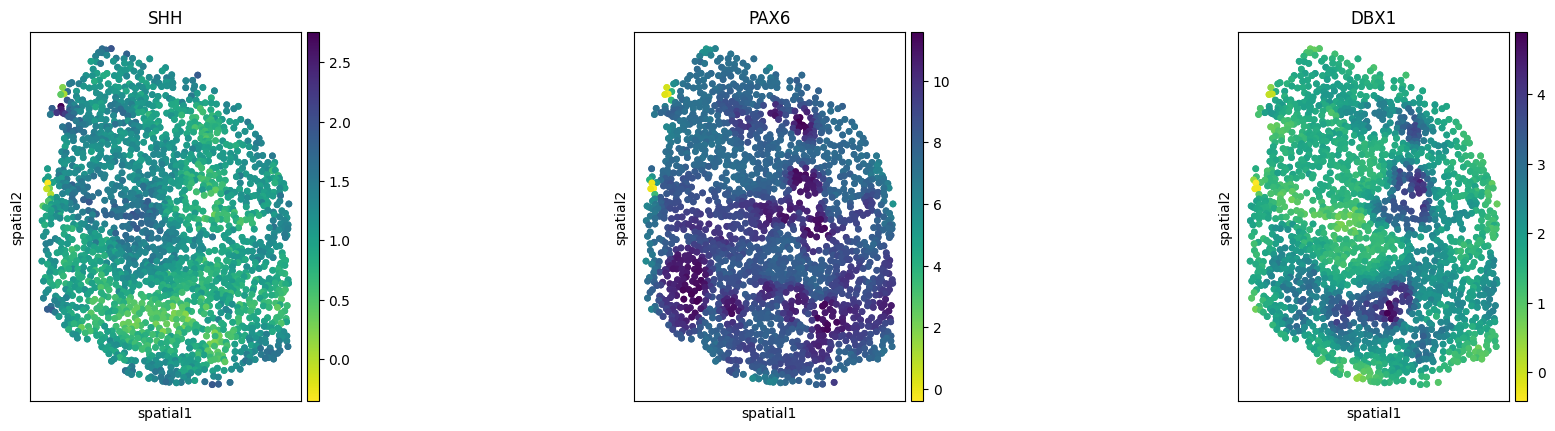

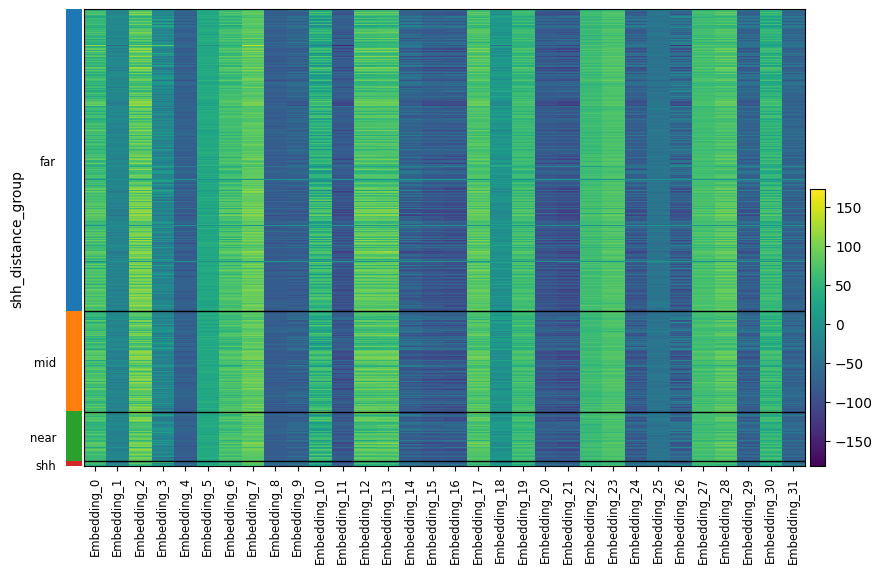

3345


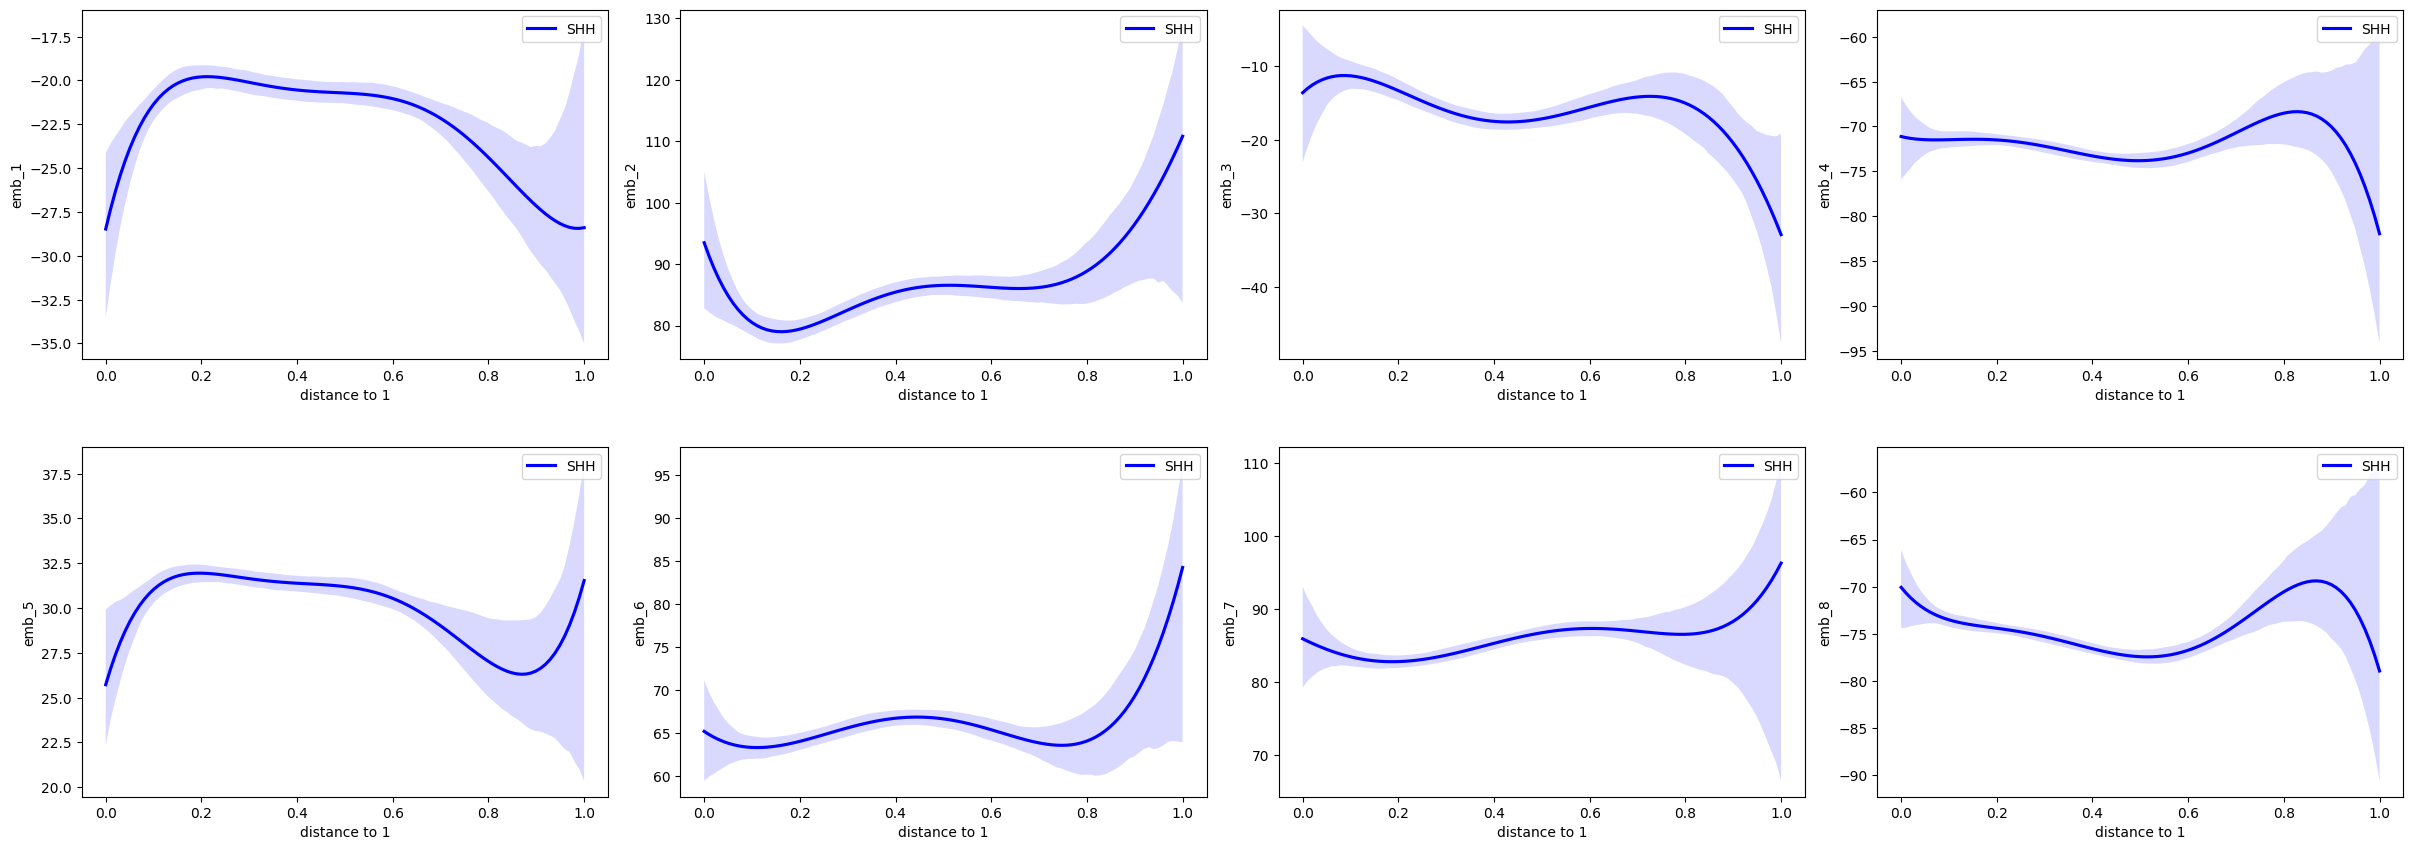

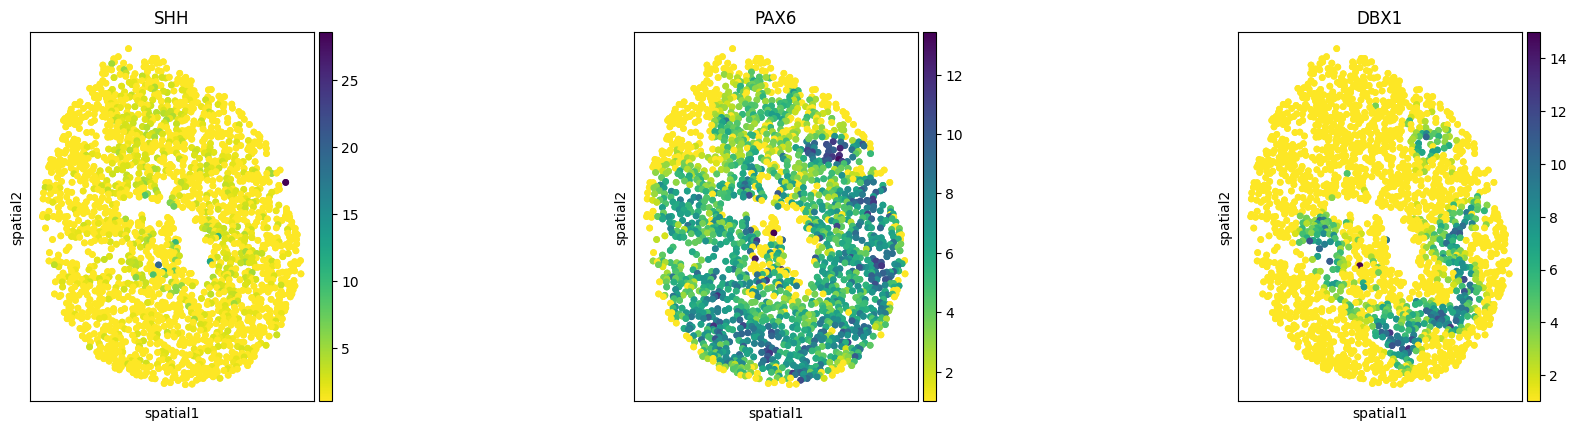

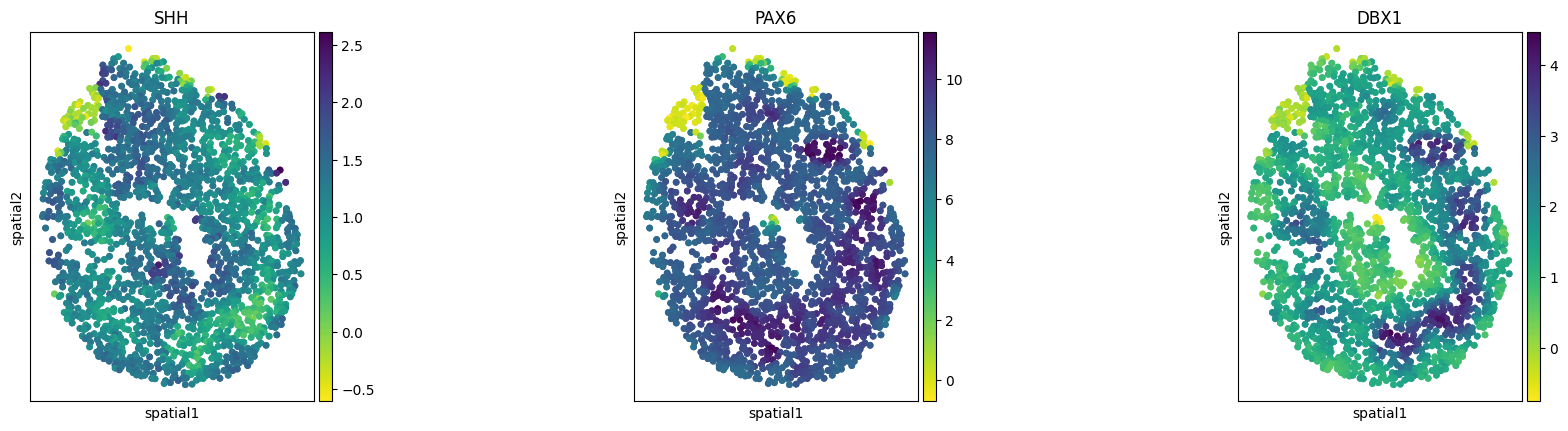

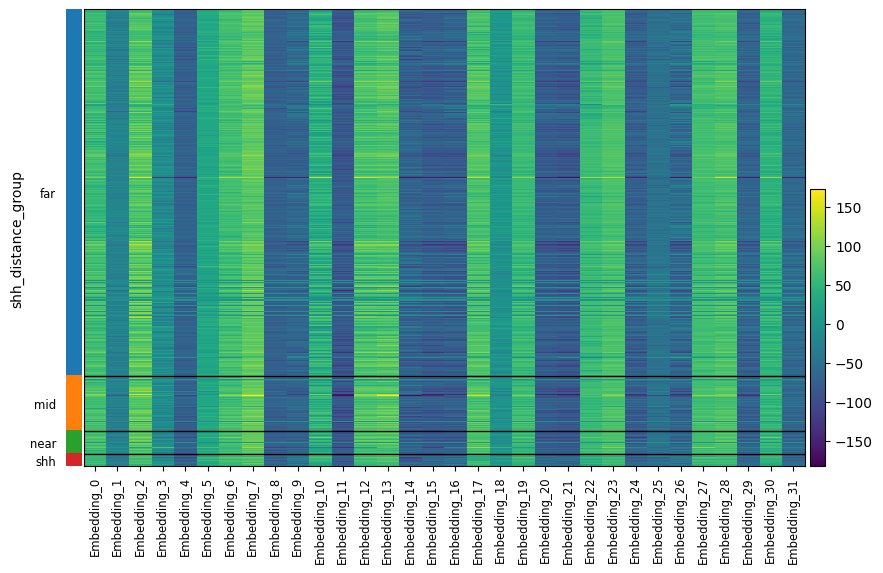

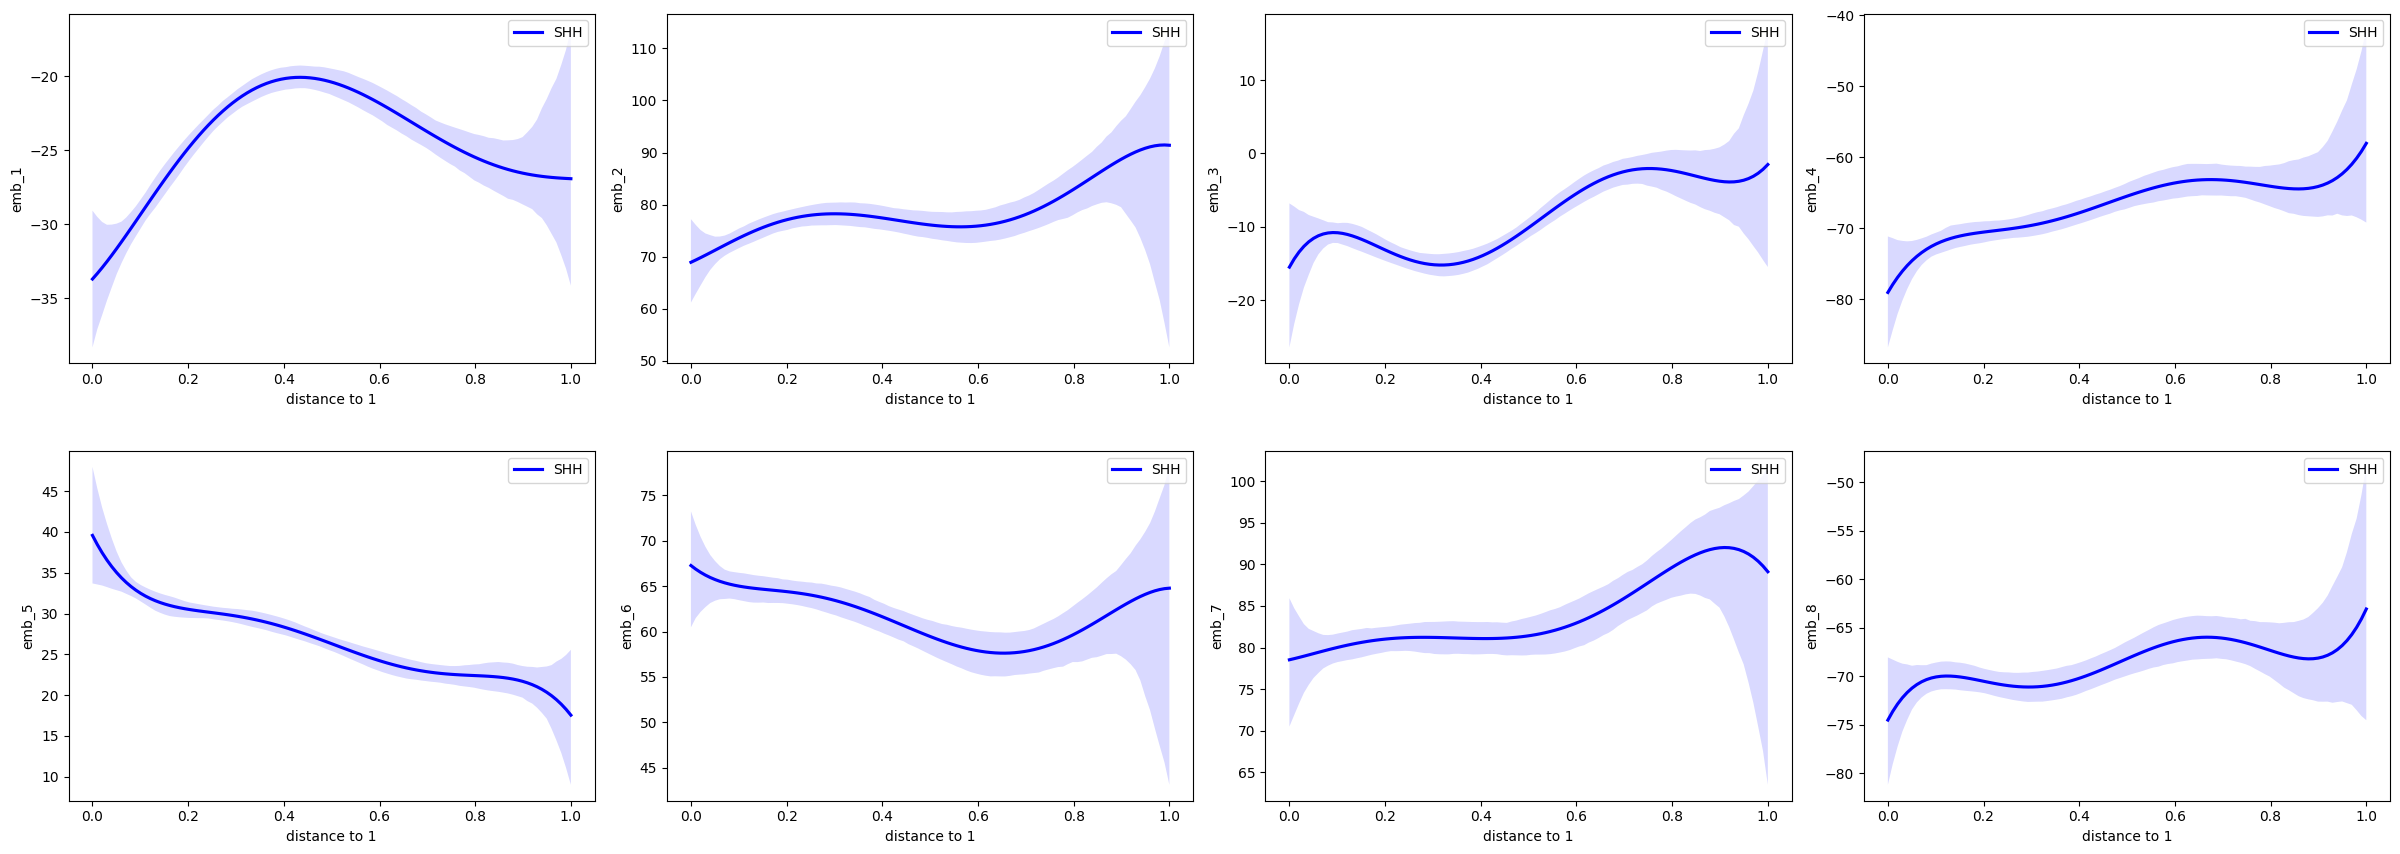

In [37]:
for i, batch in enumerate(dm.test_dataloader()):
    print(batch)
    for batch_idx in np.unique(batch.batch):
        transformer_in, transformer_out, src_padding_mask, index_nodes, dec_out = model.evaluation(batch)
        nr_cells = len(batch.obs_names[batch.batch == batch_idx])
        print(nr_cells)
        if nr_cells > 2000: 
            nr_cells = 2000
        batch_obs_names_str = batch.obs_names[batch.batch == batch_idx].numpy().astype(int).astype(str)[index_nodes[batch_idx]]
        adata.obs_names.isin(batch_obs_names_str).sum()
        sub_adata = adata[adata.obs_names.isin(batch_obs_names_str)]
        sub_adata.layers['y_rec'] = dec_out[nr_cells*batch_idx:nr_cells*(batch_idx+1)].detach().numpy()
        sq.pl.spatial_scatter(
            sub_adata,
            color = ['SHH', 'PAX6', 'DBX1'],
            layer = 'norm_ftsqrt',
            cmap = 'viridis_r',
            shape= None
        )
        sq.pl.spatial_scatter(
            sub_adata,
            color = ['SHH', 'PAX6', 'DBX1'],
            layer = 'y_rec',
            cmap = 'viridis_r',
            shape= None
        )
        evaluate_embedding_space(sub_adata, sub_adata.X, model.graph_pred_linear)

In [38]:
sub_adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 62982 stored elements and shape (2000, 88)>

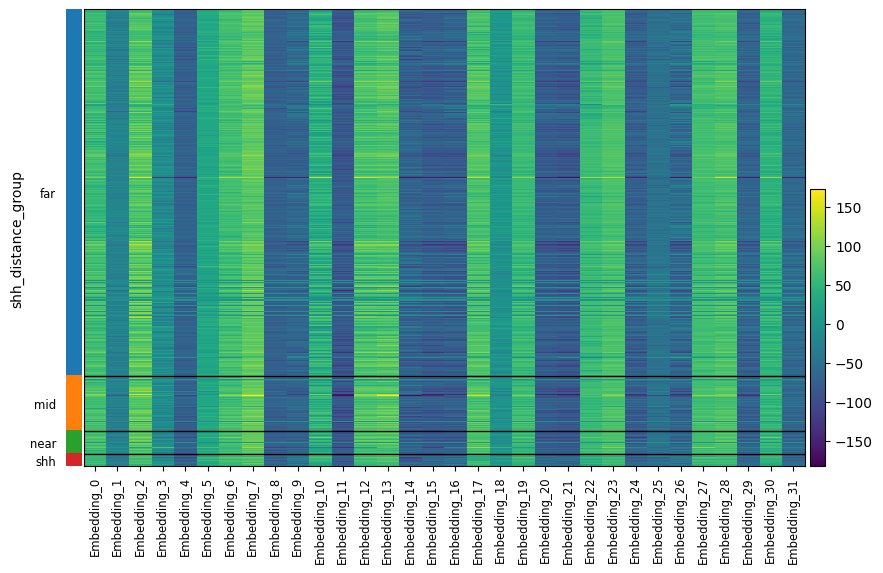

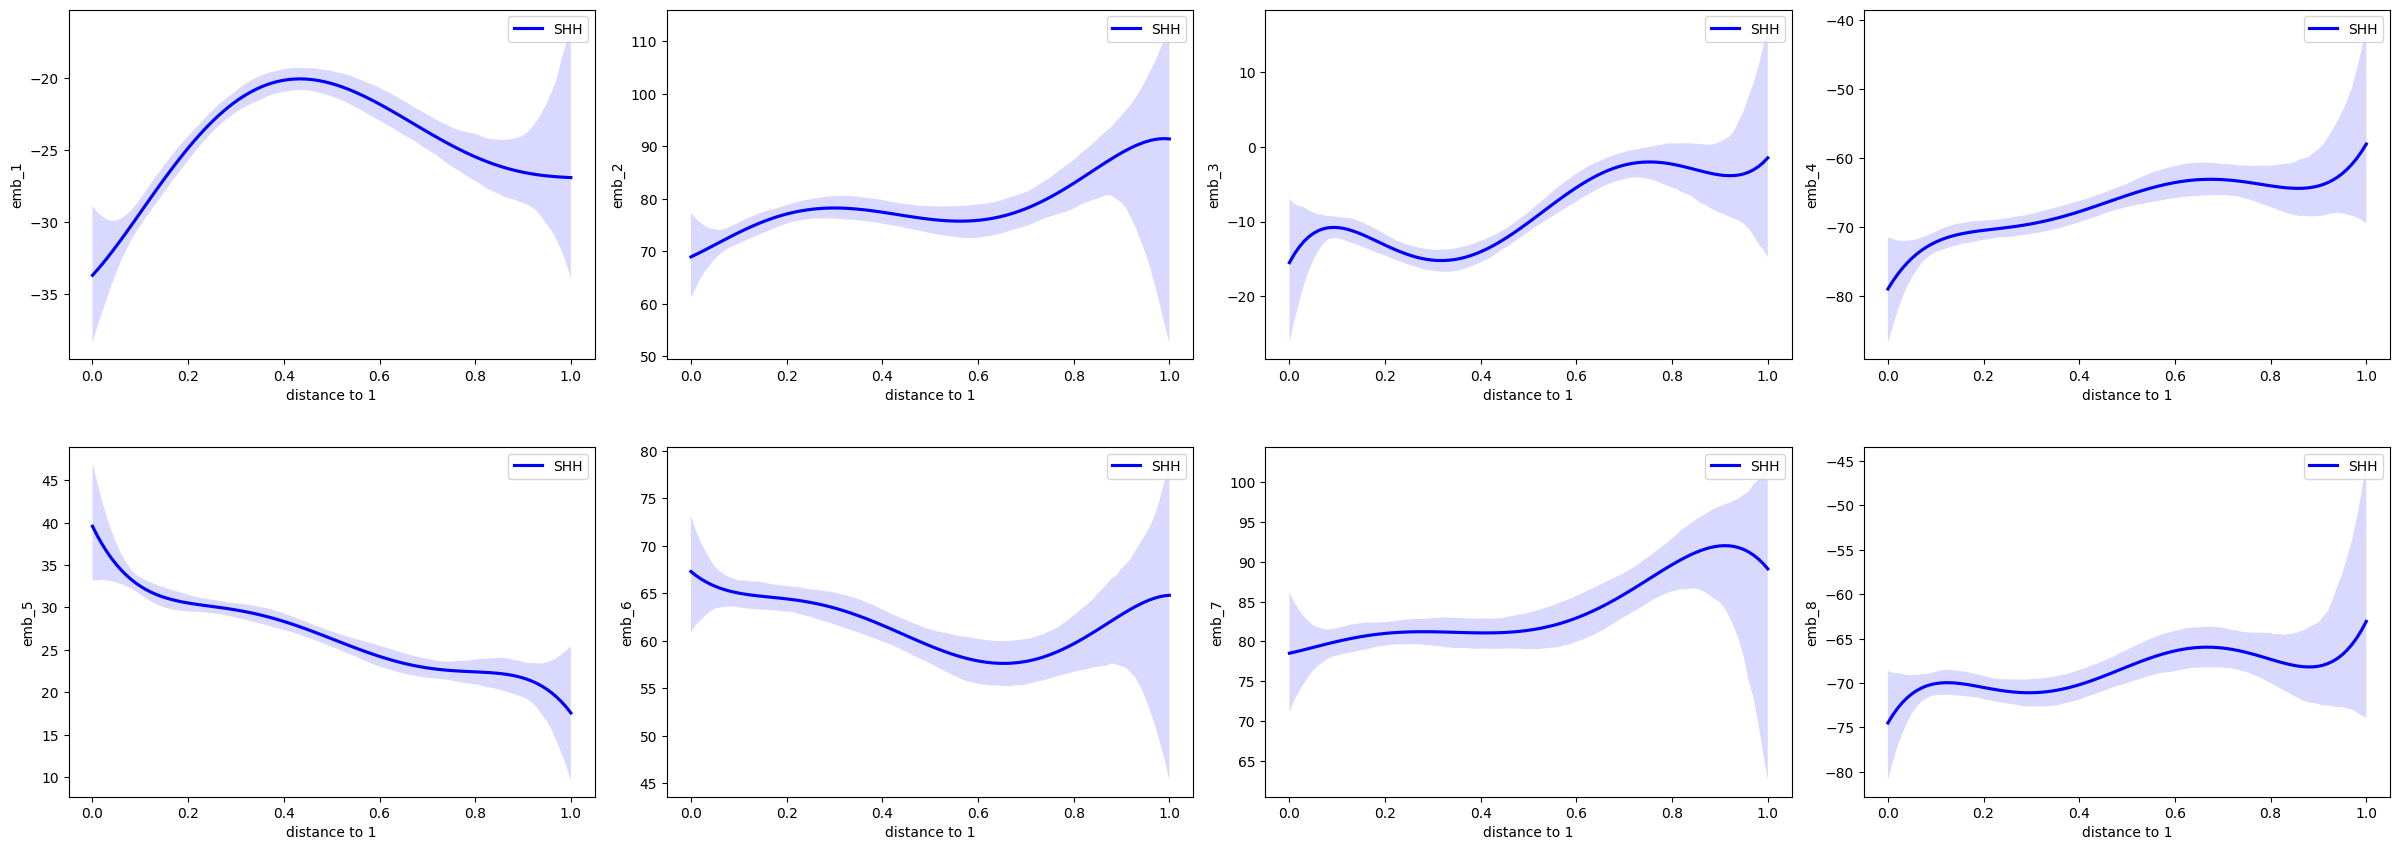

In [39]:
evaluate_embedding_space(sub_adata, sub_adata.X, model.graph_pred_linear)

In [34]:
sub_adata = adata[adata.obs_names[index_nodes[1]]]

NameError: name 'index_nodes' is not defined

In [65]:
sub_adata.layers['y_rec'] = dec_out[2000:4000].detach().numpy()

### GCN

In [48]:
for i, batch in enumerate(dm.test_dataloader()):
    print(batch)
    x, z = model.evaluation(batch)

DataBatch(x=[6644, 88], edge_index=[2, 63920], obs_names=[6644], mask=[6644], batch=[6644], ptr=[3])


ValueError: too many values to unpack (expected 2)

In [ ]:
print(x.shape, z.shape)

In [ ]:
x_list, z_list = [], []
for batch_idx in np.unique(batch.batch):
    x_list.append(x[batch.batch == batch_idx])
    z_list.append(z[batch.batch == batch_idx])

In [ ]:
print(x_list[0].shape, x_list[1].shape)

In [ ]:
sample = 'slide1_B2-1'
idx = 1

sub_adata = adata[adata.obs['sample']==sample]
print(sub_adata)
sub_adata.layers['gnn_z'] = z_list[idx].detach().numpy()
sq.pl.spatial_scatter(
    sub_adata,
    color = ['SHH'],
    layer = 'norm_ftsqrt',
    cmap = 'viridis_r',
    shape= None
)
sq.pl.spatial_scatter(
    sub_adata,
    color = ['SHH'],
    layer = 'gnn_z',
    cmap = 'viridis_r',
    shape= None
)